In [37]:
from math import sqrt
from functools import partial
import torch
from torch import nn, einsum
import torch.nn.functional as F

from einops import rearrange, reduce
from einops.layers.torch import Rearrange

# helpers

def exists(val):
    return val is not None

def cast_tuple(val, depth):
    return val if isinstance(val, tuple) else (val,) * depth

# classes

class DsConv2d(nn.Module):
    def __init__(self, dim_in, dim_out, kernel_size, padding, stride = 1, bias = True):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(dim_in, dim_in, kernel_size = kernel_size, padding = padding, groups = dim_in, stride = stride, bias = bias),
            nn.Conv2d(dim_in, dim_out, kernel_size = 1, bias = bias)
        )
    def forward(self, x):
        return self.net(x)

class LayerNorm(nn.Module):
    def __init__(self, dim, eps = 1e-5):
        super().__init__()
        self.eps = eps
        self.g = nn.Parameter(torch.ones(1, dim, 1, 1))
        self.b = nn.Parameter(torch.zeros(1, dim, 1, 1))

    def forward(self, x):
        std = torch.var(x, dim = 1, unbiased = False, keepdim = True).sqrt()
        mean = torch.mean(x, dim = 1, keepdim = True)
        return (x - mean) / (std + self.eps) * self.g + self.b

class PreNorm(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()
        self.fn = fn
        self.norm = LayerNorm(dim)

    def forward(self, x):
        return self.fn(self.norm(x))

class EfficientSelfAttention(nn.Module):
    def __init__(
        self,
        *,
        dim,
        heads,
        reduction_ratio
    ):
        super().__init__()
        self.scale = (dim // heads) ** -0.5
        self.heads = heads

        self.to_q = nn.Conv2d(dim, dim, 1, bias = False)
        self.to_kv = nn.Conv2d(dim, dim * 2, reduction_ratio, stride = reduction_ratio, bias = False)
        self.to_out = nn.Conv2d(dim, dim, 1, bias = False)

    def forward(self, x):
        h, w = x.shape[-2:]
        heads = self.heads

        q, k, v = (self.to_q(x), *self.to_kv(x).chunk(2, dim = 1))
        q, k, v = map(lambda t: rearrange(t, 'b (h c) x y -> (b h) (x y) c', h = heads), (q, k, v))

        sim = einsum('b i d, b j d -> b i j', q, k) * self.scale
        attn = sim.softmax(dim = -1)

        out = einsum('b i j, b j d -> b i d', attn, v)
        out = rearrange(out, '(b h) (x y) c -> b (h c) x y', h = heads, x = h, y = w)
        return self.to_out(out)

class MixFeedForward(nn.Module):
    def __init__(
        self,
        *,
        dim,
        expansion_factor
    ):
        super().__init__()
        hidden_dim = dim * expansion_factor
        self.net = nn.Sequential(
            nn.Conv2d(dim, hidden_dim, 1),
            DsConv2d(hidden_dim, hidden_dim, 3, padding = 1),
            nn.GELU(),
            nn.Conv2d(hidden_dim, dim, 1)
        )

    def forward(self, x):
        return self.net(x)

class MiT(nn.Module):
    def __init__(
        self,
        *,
        channels,
        dims,
        heads,
        ff_expansion,
        reduction_ratio,
        num_layers
    ):
        super().__init__()
        stage_kernel_stride_pad = ((7, 4, 3), (3, 2, 1), (3, 2, 1), (3, 2, 1))

        dims = (channels, *dims)
        dim_pairs = list(zip(dims[:-1], dims[1:]))

        self.stages = nn.ModuleList([])

        for (dim_in, dim_out), (kernel, stride, padding), num_layers, ff_expansion, heads, reduction_ratio in zip(dim_pairs, stage_kernel_stride_pad, num_layers, ff_expansion, heads, reduction_ratio):
            get_overlap_patches = nn.Unfold(kernel, stride = stride, padding = padding)
            overlap_patch_embed = nn.Conv2d(dim_in * kernel ** 2, dim_out, 1)

            layers = nn.ModuleList([])

            for _ in range(num_layers):
                layers.append(nn.ModuleList([
                    PreNorm(dim_out, EfficientSelfAttention(dim = dim_out, heads = heads, reduction_ratio = reduction_ratio)),
                    PreNorm(dim_out, MixFeedForward(dim = dim_out, expansion_factor = ff_expansion)),
                ]))

            self.stages.append(nn.ModuleList([
                get_overlap_patches,
                overlap_patch_embed,
                layers
            ]))

    def forward(
        self,
        x,
        return_layer_outputs = False
    ):
        h, w = x.shape[-2:]

        layer_outputs = []
        for (get_overlap_patches, overlap_embed, layers) in self.stages:
            x = get_overlap_patches(x)

            num_patches = x.shape[-1]
            ratio = int(sqrt((h * w) / num_patches))
            x = rearrange(x, 'b c (h w) -> b c h w', h = h // ratio)

            x = overlap_embed(x)
            for (attn, ff) in layers:
                x = attn(x) + x
                x = ff(x) + x

            layer_outputs.append(x)

        ret = x if not return_layer_outputs else layer_outputs
        return ret

class Segformer(nn.Module):
    def __init__(
        self,
        *,
        dims = (32, 64, 160, 256),
        heads = (1, 2, 5, 8),
        ff_expansion = (8, 8, 4, 4),
        reduction_ratio = (8, 4, 2, 1),
        num_layers = 2,
        channels = 3,
        decoder_dim = 256,
        num_classes = 4
    ):
        super().__init__()
        dims, heads, ff_expansion, reduction_ratio, num_layers = map(partial(cast_tuple, depth = 4), (dims, heads, ff_expansion, reduction_ratio, num_layers))
        assert all([*map(lambda t: len(t) == 4, (dims, heads, ff_expansion, reduction_ratio, num_layers))]), 'only four stages are allowed, all keyword arguments must be either a single value or a tuple of 4 values'

        self.mit = MiT(
            channels = channels,
            dims = dims,
            heads = heads,
            ff_expansion = ff_expansion,
            reduction_ratio = reduction_ratio,
            num_layers = num_layers
        )

        self.to_fused = nn.ModuleList([nn.Sequential(
            nn.Conv2d(dim, decoder_dim, 1),
            nn.Upsample(scale_factor = 2 ** i)
        ) for i, dim in enumerate(dims)])

        self.to_segmentation = nn.Sequential(
            nn.Conv2d(4 * decoder_dim, decoder_dim, 1),
            nn.Conv2d(decoder_dim, num_classes, 1),
        )

    def forward(self, x):
        layer_outputs = self.mit(x, return_layer_outputs = True)

        fused = [to_fused(output) for output, to_fused in zip(layer_outputs, self.to_fused)]
        fused = torch.cat(fused, dim = 1)
        return self.to_segmentation(fused), None

In [3]:
import rasterio
import numpy as np

def load_and_preprocess(path):
    with rasterio.open(path) as src:
        # Read all bands
        img = src.read()

        # Replace No-Data (example: -9999) with 0
        img[img == src.nodata] = 0

        # Robust Scaling (2nd and 98th percentile to remove outliers)
        p2, p98 = np.percentile(img, (2, 98))
        img = np.clip(img, p2, p98)
        img = (img - p2) / (p98 - p2)

    return img.astype(np.float32)


# Helper function to load raw mask data (without scaling or robust percentile clipping)
# Assumes single-channel mask where pixel values are class labels
def load_raw_mask(path):
    with rasterio.open(path) as src:
        mask_np = src.read()
        # Replace No-Data with 0 (or a specific background class ID)
        if src.nodata is not None:
            mask_np[mask_np == src.nodata] = 0

        # For multi-class segmentation, assume original labels are valid (e.g., 0, 1, 2, 3).
        # No remapping of non-zero values to 1 is performed here.

    return mask_np.astype(np.int64) # Masks are typically integer class labels

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import random
from functools import reduce
import itertools
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets, models
from collections import defaultdict
import torch.nn.functional as F
import torch
import torch.optim as optim
from torch.optim import lr_scheduler
import time
import copy


def plot_img_array(img_array, ncol=3):
    # Calculate nrow, ensuring at least 1 row, and rounding up
    nrow = (len(img_array) + ncol - 1) // ncol
    if nrow == 0: # Handle empty img_array case
        return

    f, plots = plt.subplots(nrow, ncol, sharex='all', sharey='all', figsize=(ncol * 4, nrow * 4))

    # Flatten the plots array for consistent indexing across all cases
    # If plt.subplots returns a single Axes object (nrow=1, ncol=1), make it an array
    if not isinstance(plots, np.ndarray):
        plots = np.array([plots])
    else:
        plots = plots.ravel() # Flatten 2D array or keep 1D array as is

    for i in range(len(img_array)):
        plots[i].imshow(img_array[i])
        plots[i].axis('off') # Turn off axes for individual plots

    # Hide any remaining empty subplots
    for i in range(len(img_array), len(plots)):
        plots[i].axis('off')

    plt.tight_layout()
    plt.show()


def plot_side_by_side(img_arrays):
    flatten_list = reduce(lambda x,y: x+y, zip(*img_arrays))

    plot_img_array(np.array(flatten_list), ncol=len(img_arrays))


def plot_errors(results_dict, title):
    markers = itertools.cycle(('+', 'x', 'o'))

    plt.title('{}'.format(title))

    for label, result in sorted(results_dict.items()):
        plt.plot(result, marker=next(markers), label=label)
        plt.ylabel('dice_coef')
        plt.xlabel('epoch')
        plt.legend(loc=3, bbox_to_anchor=(1, 0))

    plt.show()


def reverse_transform(inp):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    inp = (inp * 255).astype(np.uint8)

    return inp

def masks_to_colorimg(masks):
    # Corrected to 2 colors to match the 2 combined classes
    colors = np.asarray([(0, 255, 0), (0, 0, 255)]) # Green for class 0, Blue for class 1

    colorimg = np.ones((masks.shape[1], masks.shape[2], 3), dtype=np.float32) * 255
    channels, height, width = masks.shape

    for y in range(height):
        for x in range(width):
            selected_colors = colors[masks[:,y,x] > 0.35] # Threshold for displaying class values

            if len(selected_colors) > 0:
                colorimg[y,x,:] = np.mean(selected_colors, axis=0)

    return colorimg.astype(np.uint8)


In [5]:
from torch.utils.data import Dataset
from PIL import Image
import torch
from torchvision import transforms
import rasterio
import numpy as np

class TrainingDataset(Dataset):
    def __init__(self, image_paths, label_paths, transform=None, num_classes=4):
        self.image_paths = image_paths
        self.label_paths = label_paths
        self.transform = transform # This transform is for images
        self.num_classes = num_classes # Will always be 1 for binary segmentation
        #print("using the one with binary segmentation")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        # Load image as NumPy array (C, H, W, float32) using the provided function
        image_np = load_and_preprocess(self.image_paths[index])

        # Load mask as NumPy array (1, H, W, int64) using the new helper function
        mask_np_raw = load_raw_mask(self.label_paths[index])

        # Convert image_np (C, H, W) to a PIL Image (H, W, C) for torchvision transforms
        # which expect PIL Image for operations like Resize
        if image_np.shape[0] == 3: # Assuming RGB
            # Multiply by 255 and convert to uint8 before creating PIL Image
            image_pil = Image.fromarray((image_np.transpose(1, 2, 0) * 255).astype(np.uint8))
        elif image_np.shape[0] == 4: # Assuming RGB-NIR, take only RGB
            # Select the first 3 channels (R, G, B) and transpose for PIL
            image_pil = Image.fromarray((image_np[:3, :, :].transpose(1, 2, 0) * 255).astype(np.uint8))

        elif image_np.shape[0] == 1: # Assuming grayscale
            image_pil = Image.fromarray((image_np.squeeze(0) * 255).astype(np.uint8))
        else:
            raise ValueError(f"Unsupported image channel count: {image_np.shape[0]} for PIL conversion")

        # Apply the image transform (includes Resize, ToTensor, Normalize)
        if self.transform:
            image_tensor = self.transform(image_pil)
        else:
            # If no transform is provided, at least convert to tensor
            image_tensor = transforms.ToTensor()(image_pil)

        # Determine the target size for the mask from the transformed image
        target_size = image_tensor.shape[-2:] # Get (H, W) from the image tensor

        # Convert raw mask (1, H, W) to PyTorch Tensor (float32 for BCEWithLogitsLoss)
        mask_tensor = torch.tensor(mask_np_raw)

        # Resize the mask using nearest neighbor interpolation
        # Ensure mask_tensor is (C, H, W) for Resize, then (1, H, W) float
        mask_resized = transforms.Resize(target_size, interpolation=transforms.InterpolationMode.NEAREST)(
            mask_tensor
        )

        # For binary segmentation, the target should be a single-channel float tensor
        # (N, 1, H, W). Our mask_resized is (1, H, W) so it's ready.
        return image_tensor, mask_resized

print("TrainingDataset class defined.")

TrainingDataset class defined.


In [48]:
import os
import glob
import random
from sklearn.model_selection import train_test_split
from torchvision import transforms
from torch.utils.data import DataLoader
import torch
import numpy as np

def get_data_loaders(batch_size=4, subset_size=None, undersampling_ratio=0.0, minority_class_threshold=0.2, path = '/Users/yujiewu/SP/haiti_cropped_smaller', use_pre_disaster = False):
    base_path = path
    image_dir = os.path.join(base_path, 'images')
    label_dir = os.path.join(base_path, 'labels')
    if use_pre_disaster:
        image_dir = os.path.join(base_path, 'images-pre-disaster')
        label_dir = os.path.join(base_path, 'labels-pre-disaster') 

    all_image_paths = sorted(glob.glob(os.path.join(image_dir, '*.tif')))
    all_label_paths = sorted(glob.glob(os.path.join(label_dir, '*.tif')))

    if len(all_image_paths) != len(all_label_paths):
        raise ValueError("Mismatch between number of images and labels.")

    # Pair image and label paths
    all_pairs = list(zip(all_image_paths, all_label_paths))

    # Split all pairs into training and validation sets
    train_pairs, val_pairs = train_test_split(all_pairs, test_size=0.2, random_state=42)

    # --- Undersampling for the training set --- (not doing)
    if subset_size is not None:
        final_train_pairs = train_pairs[:subset_size]#final_train_pairs[:subset_size]
        val_pairs = val_pairs[:subset_size // 4] # Keep validation subset smaller if train is subsetted
    #else:
    #  val_pairs = val_pairs[:len(final_train_pairs) // 4]
    train_image_paths = [p[0] for p in train_pairs]#final_train_pairs]
    train_label_paths = [p[1] for p in train_pairs]#final_train_pairs]

    val_image_paths = [p[0] for p in val_pairs]
    val_label_paths = [p[1] for p in val_pairs]

    print(f"Training images (using pre-undersampled drive): {len(train_image_paths)}")
    print(f"Validation images: {len(val_image_paths)}")

    # Define image transformations
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    image_size = (256, 256) # Define target image size, further reduced for faster verification
    #print(f"get_data_loaders: Setting image_size to {image_size}")

    train_transform = transforms.Compose([
        transforms.Resize(image_size),
        #transforms.RandomHorizontalFlip(),
        #transforms.RandomVerticalFlip(),
        #transforms.RandomRotation(degrees=10),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std)
    ])

    val_transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std)
    ])

    train_dataset = TrainingDataset(
        image_paths=train_image_paths,
        label_paths=train_label_paths,
        transform=train_transform
    )

    val_dataset = TrainingDataset(
        image_paths=val_image_paths,
        label_paths=val_label_paths,
        transform=val_transform
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        drop_last=True # Add drop_last=True here
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        drop_last=True # Add drop_last=True here for consistency
    )

    return {'train': train_loader, 'val': val_loader}

print("Function `get_data_loaders` defined with undersampling capability.")

Function `get_data_loaders` defined with undersampling capability.


In [7]:
def process_mask_for_cross_entropy(mask_tensor, target_size, num_output_classes, ignore_index=255):
    # mask_tensor: (1, H_orig, W_orig) with values 0, 1, 2, 3, 4
    # num_output_classes: 4 (for no-damage, minor, major, destroyed)

    # Create an empty tensor for remapped labels, filled with ignore_index
    # Use torch.full_like for creating a tensor with the same properties as mask_tensor
    remapped_labels = torch.full(mask_tensor.shape, fill_value=ignore_index, dtype=torch.long, device=mask_tensor.device)

    # Remap original labels (1, 2, 3, 4) to new labels (0, 1, 2, 3)
    # Original 0 ('un-classified') will remain `ignore_index`
    for original_val in range(1, 5): # Iterate through original classes 1 ('no-damage') to 4 ('destroyed')
        new_val = original_val - 1 # New classes 0 to 3
        remapped_labels[mask_tensor == original_val] = new_val

    # Resize the remapped labels to the target_size
    # Squeeze and unsqueeze are used to handle the channel dimension for transforms.Resize
    resized_labels_with_channel = transforms.Resize(target_size, interpolation=transforms.InterpolationMode.NEAREST)(
        remapped_labels.squeeze(0).unsqueeze(0) # (H_orig, W_orig) -> (1, H_orig, W_orig) -> (1, H_new, W_new)
    )
    return resized_labels_with_channel.squeeze(0) # Returns (H_new, W_new) tensor with integer class labels


In [24]:
def dice_loss(pred, target, smooth=1.):
    pred = pred.contiguous()
    target = target.contiguous()

    intersection = (pred * target).sum(dim=2).sum(dim=2)

    loss = (1 - ((2. * intersection + smooth) / (pred.sum(dim=2).sum(dim=2) + target.sum(dim=2).sum(dim=2) + smooth)))

    return loss


class BoundaryAwareLoss(nn.Module):
    def __init__(self, num_classes, ignore_index=0, boundary_weight=5.0):
        super().__init__()
        self.ignore_index     = ignore_index
        self.boundary_weight  = boundary_weight
        self.ce               = nn.CrossEntropyLoss(
                                    ignore_index=ignore_index,
                                    reduction='none')   # per-pixel loss

    def forward(self, logits, targets):
        # base per-pixel CE loss: (B, H, W)
        # logits is (B, C, H, W) and targets is (B, H, W) with class labels, we need to ensure targets are in the correct format for CrossEntropyLoss
        logits = logits.squeeze(1)
        per_pixel_loss = self.ce(logits, targets)

        # find boundary pixels from ground truth
        valid_targets = targets.clone()
        valid_targets[targets == self.ignore_index] = 0
        boundary = get_boundary_mask(valid_targets)     # (B, 1, H, W)
        boundary = boundary.squeeze(1)                  # (B, H, W)

        # upweight boundary pixels
        weight_map = 1.0 + (self.boundary_weight - 1.0) * boundary

        # apply weights and mean
        weighted_loss = (per_pixel_loss * weight_map).mean()
        return weighted_loss


criterion = BoundaryAwareLoss(
    num_classes=5,
    ignore_index=0,
    boundary_weight=5.0   # boundary pixels are 5x more penalized
)

def get_boundary_mask(mask, kernel_size=3):
    """
    Finds boundary pixels in a label mask using morphological operations.
    Returns a binary mask: 1 = boundary pixel, 0 = interior pixel.
    """
    # one-hot encode the mask: (B, Channels, H, W)
    num_classes = mask.max().item() + 1
    mask = mask.squeeze(1).long() # (B, H, W)
    mask_one_hot = F.one_hot(mask, num_classes) # (B, H, W, Classes)
    #print("shape:", mask_one_hot.shape, "ndim:", mask_one_hot.ndim)
    perm = (0, 3, 1, 2)
    #print("perm match:", len(perm) == mask_one_hot.ndim)
    mask_one_hot = mask_one_hot.permute(0, 3, 1, 2).float()

    # dilate and erode each class channel
    pad = kernel_size // 2
    pooled = F.max_pool2d(mask_one_hot,
                          kernel_size=kernel_size,
                          stride=1,
                          padding=pad)

    # boundary = where dilation differs from original (edge pixels)
    boundary = (pooled != mask_one_hot).any(dim=1, keepdim=True).float()
    return boundary  # (B, 1, H, W)

def calc_loss(pred, target, metrics, class_weights=None, ignore_index = 0, boundary_weight = 3.0, boundary_logits = None):
    device = pred.device

    # Handle class weights
    if class_weights is not None:
        if not isinstance(class_weights, torch.Tensor):
            class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)
        class_weights = class_weights.to(device)

        # Cross-Entropy Loss
        # F.cross_entropy expects input (N, C, H, W) and target (N, H, W)
        # It applies softmax implicitly on the input logits.
        # Squeeze the target to remove the channel dimension (1, H, W) -> (H, W)
    ce_loss = F.cross_entropy(pred, target.squeeze(1), weight=class_weights, ignore_index=ignore_index, reduction='mean')
    avg_loss = ce_loss

    # Boundary aware loss
    if boundary_logits is not None:
        valid_targets = target.clone()
        valid_targets[target == ignore_index] = 0
        boundary = get_boundary_mask(valid_targets)     # (B, 1, H, W)
        boundary = boundary.squeeze(1)                  # (B, H, W)

        # upweight boundary pixels
        weight_map = 1.0 + (boundary_weight - 1.0) * boundary

        # apply weights and mean
        weighted_loss = (ce_loss * weight_map).mean()
        # Update metrics
        metrics['loss'] += ce_loss.item() * target.size(0) # target.size(0) is batch size
        metrics['boundary loss'] += weighted_loss.item() * target.size(0) # target.size(0) is batch size
        # We can add accuracy or other metrics if desired, but for now, just loss.

        avg_loss = ce_loss * 0.5 + weighted_loss * 0.5 # Combine original CE loss and boundary-weighted loss
    #print(f"CE Loss: {ce_loss.item():.4f}, Boundary Weighted Loss: {weighted_loss.item():.4f}, Combined Loss: {avg_loss.item():.4f}")
    return avg_loss
    '''
    # Ensure pos_weight is on the correct device if provided
    if pos_weight is not None:
        pos_weight = pos_weight.to(pred.device)
        bce = F.binary_cross_entropy_with_logits(pred, target, pos_weight=pos_weight)
    else:
        bce = F.binary_cross_entropy_with_logits(pred, target)

    # Apply sigmoid for Dice loss calculation
    pred_sigmoid = torch.sigmoid(pred)
    # dice_loss returns a tensor of shape (N, 1) where each element is (1 - Dice_score)
    dice_per_sample = dice_loss(pred_sigmoid, target)

    # For Dice loss, typically mean over samples is taken.
    weighted_dice = dice_per_sample.mean()

    loss = bce * bce_weight + weighted_dice * (1 - bce_weight)

    metrics['bce'] += bce.data.cpu().numpy() * target.size(0)
    metrics['dice'] += weighted_dice.data.cpu().numpy() * target.size(0)
    metrics['loss'] += loss.data.cpu().numpy() * target.size(0)

    return loss
    '''

def remap_labels(mask_tensor, ignore_index=255):
    # mask_tensor: (1, H, W) with values 0, 1, 2, 3, 4
    # Create an empty tensor for remapped labels, filled with ignore_index
    remapped_labels = torch.full(mask_tensor.shape, fill_value=ignore_index, dtype=torch.long, device=mask_tensor.device)

    # Remap original labels (1, 2, 3, 4) to new labels (0, 1, 2, 3)
    # Original 0 ('un-classified') will remain `ignore_index`
    for original_val in range(1, 5): # Iterate through original classes 1 ('no-damage') to 4 ('destroyed')
        new_val = original_val - 1 # New classes 0 to 3
        remapped_labels[mask_tensor == original_val] = new_val

    return remapped_labels.squeeze(0) # Returns (H, W) tensor with integer class labels


def print_metrics(metrics, epoch_samples, phase):
    outputs = []
    for k in metrics.keys():
        outputs.append("{}: {:4f}".format(k, metrics[k] / epoch_samples))

    print("{}: {}".format(phase, ", ".join(outputs)))


In [ ]:
# pre train on pre-disaster images?
from torch import device

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

epochs = 30 #1 epoch is 19s

model = Segformer(
    dims=(30, 64, 160, 256),
    heads=(1, 2, 5, 8),
    ff_expansion=(8, 8, 4, 4),
    reduction_ratio=(8, 4, 2, 1),
    num_layers=(2, 2, 2, 2),
    channels=3,
    decoder_dim=256,
    num_classes=1 # Output classes for no-damage, minor damage, major damage, destroyed
).to(device)

#get dataloaders
dataloaders = get_data_loaders(batch_size=4, subset_size=None,  )
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# pos_weight=10 because boundary pixels are far fewer than interior pixels

history = defaultdict(list)

for epoch in range(epochs):
    print('Epoch {}/{}'.format(epoch, epochs - 1))
    print('-' * 10)

    model.train() # Set model to training mode
    total_loss = 0
    metrics = defaultdict(float) # Initialize metrics for calc_loss
    epoch_samples = 0
    since = time.time()
    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()  # Set model to training mode
        else:
            model.eval()  # Set model to evaluate mode

        for images, masks in dataloaders[phase]: # Correctly iterate over the training DataLoader
            images = images.to(device)
            masks = masks.to(device)
            z = masks.size()
            #print(z[3])
            masks_processed = process_mask_for_cross_entropy(masks, (z[2], z[3]), 4)

            optimizer.zero_grad()
            preds, _ = model(images)                            # (B, 5, 64, 64)
            preds = F.interpolate(preds, size=(256, 256), mode='bilinear', align_corners=False)                   # (B, 5, 256, 256)
            #print(f"Preds shape: {preds.shape}, Masks shape: {masks_processed.shape}") # Debugging shapes before loss calculation
            #print(f"Unique values in masks_processed: {torch.unique(preds)}") # Debugging unique class labels in the processed mask

            # Use calc_loss from previous cell
            loss = calc_loss(preds, masks_processed, metrics, boundary_logits=None) # calc_loss also updates metrics
            
            if phase == 'train':
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0) # Accumulate weighted loss
            epoch_samples += images.size(0)

        
        history[f'{phase}_loss'].append(total_loss/epoch_samples)

        # Print metrics for the training phase after each epoch
    print_metrics(metrics, epoch_samples, 'train')
    print(f"Epoch {epoch+1}, Average Loss: {total_loss/epoch_samples:.4f}")
    time_elapsed = time.time() - since
    print('{:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))

    # Store metrics in history

# Optional: Add validation phase if desired, similar to train_model function

print("Training complete.")

In [45]:

from torch import device

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

epochs = 30 #1 epoch is 19s

model = Segformer(
    dims=(30, 64, 160, 256),
    heads=(1, 2, 5, 8),
    ff_expansion=(8, 8, 4, 4),
    reduction_ratio=(8, 4, 2, 1),
    num_layers=(2, 2, 2, 2),
    channels=3,
    decoder_dim=256,
    num_classes=4 # Output classes for no-damage, minor damage, major damage, destroyed
).to(device)

#get dataloaders
dataloaders = get_data_loaders(batch_size=4, subset_size=None)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
seg_criterion      = BoundaryAwareLoss(num_classes=5, ignore_index=0)
boundary_criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([10.0]).to(device))
# pos_weight=10 because boundary pixels are far fewer than interior pixels

history = defaultdict(list)

for epoch in range(epochs):
    print('Epoch {}/{}'.format(epoch, epochs - 1))
    print('-' * 10)

    model.train() # Set model to training mode
    total_loss = 0
    metrics = defaultdict(float) # Initialize metrics for calc_loss
    epoch_samples = 0
    since = time.time()
    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()  # Set model to training mode
        else:
            model.eval()  # Set model to evaluate mode

        for images, masks in dataloaders[phase]: # Correctly iterate over the training DataLoader
            images = images.to(device)
            masks = masks.to(device)
            z = masks.size()
            #print(z[3])
            masks_processed = process_mask_for_cross_entropy(masks, (z[2], z[3]), 4)

            optimizer.zero_grad()
            preds, _ = model(images)                            # (B, 5, 64, 64)
            preds = F.interpolate(preds, size=(256, 256), mode='bilinear', align_corners=False)                   # (B, 5, 256, 256)
            #print(f"Preds shape: {preds.shape}, Masks shape: {masks_processed.shape}") # Debugging shapes before loss calculation
            #print(f"Unique values in masks_processed: {torch.unique(preds)}") # Debugging unique class labels in the processed mask

            # Use calc_loss from previous cell
            loss = calc_loss(preds, masks_processed, metrics, boundary_logits=None) # calc_loss also updates metrics
            
            if phase == 'train':
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0) # Accumulate weighted loss
            epoch_samples += images.size(0)

        
        history[f'{phase}_loss'].append(total_loss/epoch_samples)

        # Print metrics for the training phase after each epoch
    print_metrics(metrics, epoch_samples, 'train')
    print(f"Epoch {epoch+1}, Average Loss: {total_loss/epoch_samples:.4f}")
    time_elapsed = time.time() - since
    print('{:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))

    # Store metrics in history

# Optional: Add validation phase if desired, similar to train_model function

print("Training complete.")

Training images (using pre-undersampled drive): 281
Validation images: 71
Epoch 0/29
----------
train: 
Epoch 1, Average Loss: 0.5139
0m 16s
Epoch 1/29
----------
train: 
Epoch 2, Average Loss: 0.3978
0m 16s
Epoch 2/29
----------
train: 
Epoch 3, Average Loss: 0.3812
0m 17s
Epoch 3/29
----------
train: 
Epoch 4, Average Loss: 0.3612
0m 16s
Epoch 4/29
----------
train: 
Epoch 5, Average Loss: 0.3659
0m 16s
Epoch 5/29
----------
train: 
Epoch 6, Average Loss: 0.3598
0m 16s
Epoch 6/29
----------
train: 
Epoch 7, Average Loss: 0.3430
0m 16s
Epoch 7/29
----------
train: 
Epoch 8, Average Loss: 0.3307
0m 16s
Epoch 8/29
----------
train: 
Epoch 9, Average Loss: 0.3311
0m 16s
Epoch 9/29
----------
train: 
Epoch 10, Average Loss: 0.3234
0m 17s
Epoch 10/29
----------
train: 
Epoch 11, Average Loss: 0.2981
0m 16s
Epoch 11/29
----------
train: 
Epoch 12, Average Loss: 0.3075
0m 16s
Epoch 12/29
----------
train: 
Epoch 13, Average Loss: 0.3067
0m 16s
Epoch 13/29
----------
train: 
Epoch 14, Average

/var/folders/qm/2xjt0q2x33z9bn69ybd177z80000gp/T/ipykernel_14940/4065437771.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc=3, bbox_to_anchor=(1, 0))


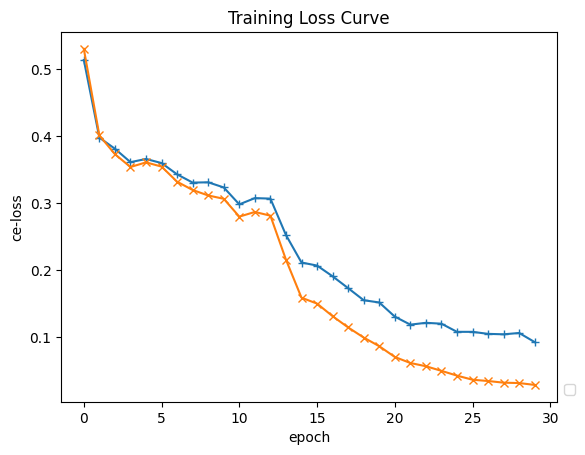

In [46]:

# Plot the learning curves
#plot_errors(history['loss'], title=)
markers = itertools.cycle(('+', 'x', 'o'))

plt.title('{}'.format('Training Loss Curve'))

#for label, result in sorted(results_dict.items()):
plt.plot(history['val_loss'], marker=next(markers))
plt.plot(history['train_loss'], marker=next(markers))
plt.ylabel('ce-loss')
plt.xlabel('epoch')
plt.legend(loc=3, bbox_to_anchor=(1, 0))

plt.show()

Training images (using pre-undersampled drive): 281
Validation images: 71
torch.Size([1, 3, 256, 256])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000001].


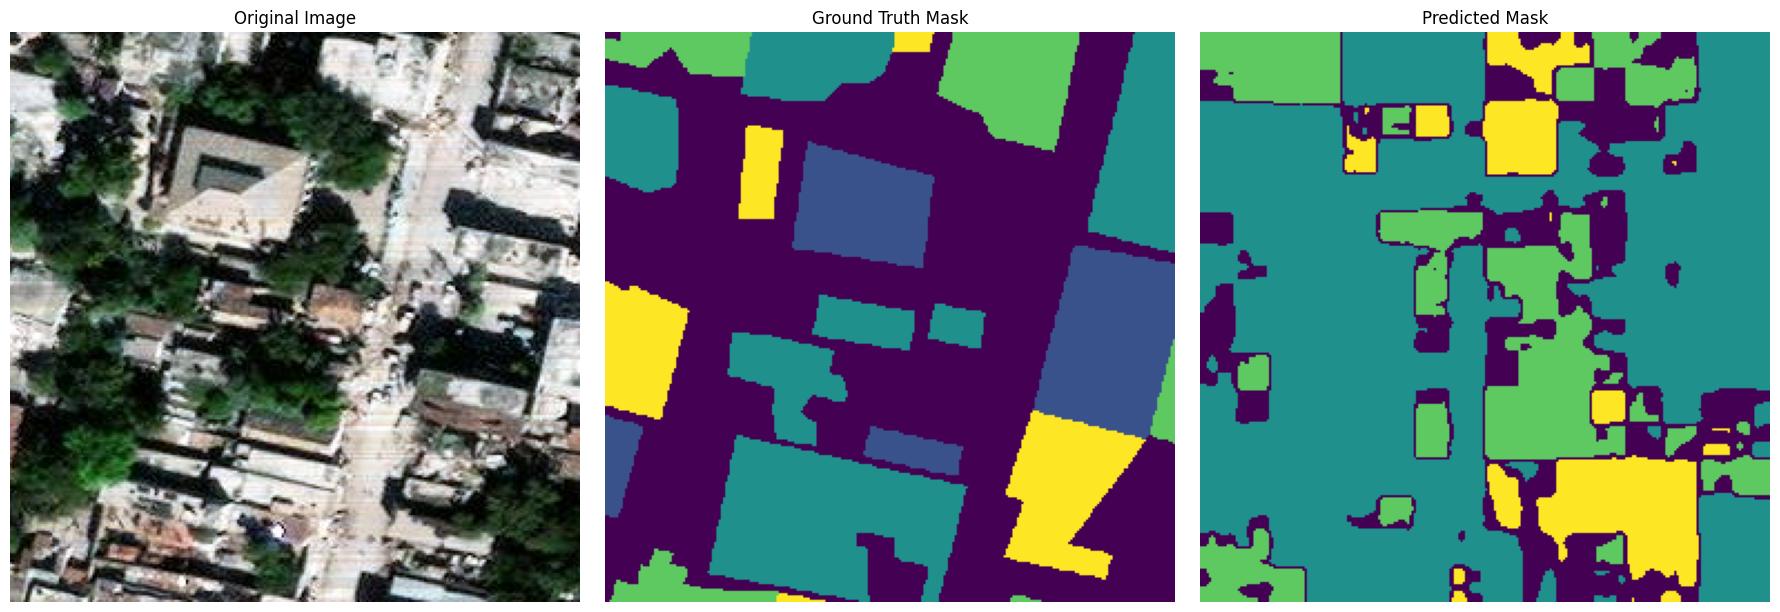

In [47]:
from sklearn.preprocessing import MinMaxScaler

num_class = 4
BACKGROUND_THRESHOLD = 0.6  # if max class prob is below this, classify as background

dataloader = get_data_loaders(batch_size=1)
val_dataset = dataloader['val']

data_iter = iter(val_dataset)
first_batch = next(data_iter)
inputs, labels = first_batch

idx = 0
print(inputs.shape)

original_image_display = np.transpose(inputs[idx], (1, 2, 0)).numpy()
scaler = MinMaxScaler()
original_image_display = [scaler.fit_transform(original_image_display[x]) for x in range(original_image_display.shape[0])]

inputs = inputs.to(device)

#model.eval()
with torch.no_grad():
    outputs, _ = model(inputs)
    logits = F.softmax(outputs, dim=1)

# Resize logits to match ground truth label size
resized_logits = torch.nn.functional.interpolate(
    logits,
    size=labels.shape[-2:],
    mode="bilinear",
    align_corners=False
)  # shape: (1, 4, H, W)

# Get the max probability and argmax across the 4 damage classes
max_probs, argmax_classes = resized_logits.max(dim=1)  # both: (1, H, W)

# Shift damage class indices by 1 (0→1, 1→2, 2→3, 3→4)
# then assign 0 (background) where max prob is below threshold
predicted_mask_tensor = (argmax_classes + 1).squeeze(0)  # (H, W), values 1–4
max_probs_squeezed = max_probs.squeeze(0)                 # (H, W)

predicted_mask_tensor[max_probs_squeezed < BACKGROUND_THRESHOLD] = 0

predicted_mask_np = predicted_mask_tensor.cpu().numpy()  # values: 0–4

# Ground truth
ground_truth_mask_np = labels.cpu().numpy()
colored_ground_truth = np.transpose(ground_truth_mask_np[0], (1, 2, 0))

# --- Colormap for 5 classes ---
# 0=background(black), 1=undamaged(green), 2=minor(yellow), 3=major(orange), 4=destroyed(red)
class_colors = np.array([
    [0,   0,   0  ],  # 0 - background
    [0,   200, 0  ],  # 1 - undamaged
    [255, 255, 0  ],  # 2 - minor damage
    [255, 140, 0  ],  # 3 - major damage
    [200, 0,   0  ],  # 4 - destroyed
], dtype=np.uint8)

def mask_to_color(mask_np, colors):
    """Convert an integer class mask (H, W) to an RGB image using a color lookup table."""
    h, w = mask_np.shape
    color_img = colors[mask_np.astype(int)]  # (H, W, 3)
    return color_img

#colored_prediction_rgb = mask_to_color(predicted_mask_np, class_colors)

'''
# --- Legend patch helper ---
from matplotlib.patches import Patch
class_names = ['Background', 'Undamaged', 'Minor Damage', 'Major Damage', 'Destroyed']
legend_elements = [
    Patch(facecolor=np.array(class_colors[i]) / 255.0, label=class_names[i])
    for i in range(5)
]
'''
# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(original_image_display)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(colored_ground_truth, cmap='viridis')
axes[1].set_title('Ground Truth Mask')
axes[1].axis('off')

axes[2].imshow(predicted_mask_np, cmap='viridis')
axes[2].set_title('Predicted Mask')
axes[2].axis('off')
#axes[2].legend(handles=legend_elements, loc='lower right', fontsize=8, framealpha=0.7)

plt.tight_layout()
plt.show()

In [41]:
import torch
import numpy as np

class SegmentationMetrics:
    """
    Accumulates a confusion matrix over the full val set,
    then computes per-class and mean IoU + F1.
    """
    def __init__(self, num_classes: int, class_names: list[str], ignore_index: int = 255):
        self.num_classes = num_classes
        self.class_names = class_names
        self.ignore_index = ignore_index
        self.reset()

    def reset(self):
        self.confusion_matrix = np.zeros((self.num_classes, self.num_classes), dtype=np.int64)

    def update(self, preds: torch.Tensor, targets: torch.Tensor):
        """
        preds:   (B, H, W) — argmax class indices
        targets: (B, H, W) — ground truth class indices
        """
        preds = preds.cpu().numpy().flatten()
        targets = targets.cpu().numpy().flatten()

        # Mask out ignored pixels
        mask = targets != self.ignore_index
        preds, targets = preds[mask], targets[mask]

        # Accumulate into confusion matrix
        indices = self.num_classes * targets + preds
        counts = np.bincount(indices, minlength=self.num_classes ** 2)
        self.confusion_matrix += counts.reshape(self.num_classes, self.num_classes)

    def compute(self) -> dict:
        cm = self.confusion_matrix  # shape: (C, C)

        # Per-class IoU
        tp = np.diag(cm)                          # true positives per class
        fp = cm.sum(axis=0) - tp                  # false positives
        fn = cm.sum(axis=1) - tp                  # false negatives

        iou = tp / (tp + fp + fn + 1e-6)

        # Per-class F1
        precision = tp / (tp + fp + 1e-6)
        recall    = tp / (tp + fn + 1e-6)
        f1 = 2 * precision * recall / (precision + recall + 1e-6)

        results = {
            "per_class_iou":  dict(zip(self.class_names, iou)),
            "per_class_f1":   dict(zip(self.class_names, f1)),
            "miou":           float(np.mean(iou)),
            "mean_f1":        float(np.mean(f1)),
        }
        return results
    
dataloader = get_data_loaders()
# Get a sample from the validation dataset
val_dataset = dataloader['val']
metrics_calculator = SegmentationMetrics(num_classes=4, class_names=["no damage", "minor damage", "major damage", "destroyed"], ignore_index=255)
#iterate through entire val dataset and calculate mIoU for each class and mean IoU
ious_per_class = []
mean_ious = []
for inputs, labels in val_dataset:
    inputs = inputs.to(device)
    labels = labels.to(device)

    with torch.no_grad():
        outputs, _ = model(inputs)
        logits = F.softmax(outputs, dim=1)

    predicted_mask_tensor = torch.nn.functional.interpolate(
        logits,
        size=labels.shape[-2:], # target size is H, W of the ground truth label
        mode="bilinear",
        align_corners=False
    ).argmax(dim=1)

    labels = remap_labels(labels) # Remap labels to 0,1,2,3 with ignore_index=255 for unclassified

    # Update IoU metrics
    #print(f"Updating IoU metrics for batch with shape: {predicted_mask_tensor.shape} and labels shape: {labels.squeeze(1).shape}")
    #print(f"Unique values in labels: {torch.unique(labels)}")
    metrics_calculator.update(predicted_mask_tensor.cpu(), labels.cpu())

results = metrics_calculator.compute()
print("Per-class IoU:", results["per_class_iou"])
print("Per-class F1:", results["per_class_f1"])
print("Mean IoU:", results["miou"])
print("Mean F1:", results["mean_f1"])

Training images (using pre-undersampled drive): 281
Validation images: 71
Per-class IoU: {'no damage': np.float64(0.0), 'minor damage': np.float64(0.4060011153172856), 'major damage': np.float64(0.3504492736156373), 'destroyed': np.float64(0.29174545293150034)}
Per-class F1: {'no damage': np.float64(0.0), 'minor damage': np.float64(0.5775255591063831), 'major damage': np.float64(0.5190108960530855), 'destroyed': np.float64(0.4517068426603255)}
Mean IoU: 0.2620489604661058
Mean F1: 0.38706082445494855
